# Q2 Trajectories, Optimization & Selecting K

We now have a per-session progress score (0–3) for every client from Q1. These scores form a
**cumulative progress trajectory** for each child across the 12-session care pathway.

This notebook:
1. Builds cumulative trajectories and clusters them with K-means for K = 2–6
2. Applies the newsvendor-style audit model to derive an optimal reassessment session Q* per cluster
3. Selects K based on policy distinctness and cluster interpretability
4. Produces the three required plots and the summary table

In [53]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# ── Constants ──────────────────────────────────────────────────────────────
TMAX     = 12
ALPHA    = 0.90
SESSIONS = np.arange(1, TMAX + 1)
K_RANGE  = range(2, 7)
COLORS   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

SCORED_PATH   = Path("data/scored_notes.csv")
FEATURES_PATH = Path("data/client_features.csv")
WAITLIST_PATH = Path("data/waitlist.csv")

print("Imports OK")

Imports OK


## Part (a) — Build the Clustering Model

**Pipeline:**
1. Load per-session scores from `scored_notes.csv` (already on the 0–3 scale from Q1)
2. Construct a 12-point cumulative progress trajectory per client:
   Session 1 = 0 (baseline), each subsequent point adds the transition score
3. Apply K-means for K = 2, 3, 4, 5, 6
4. Generate spaghetti plots for each K

In [54]:
# ── Load scored notes and build trajectories ───────────────────────────────
scored = pd.read_csv(SCORED_PATH)
print(f"Scored notes: {len(scored)} rows, {scored['client_id'].nunique()} clients")

trajectories = {}
for cid, grp in scored.groupby("client_id"):
    grp = grp.sort_values("session")
    scores = grp["score"].values          # 11 transition scores (sessions 2–12)
    cumtraj = np.concatenate([[0], np.cumsum(scores)])   # 12-point trajectory
    trajectories[cid] = cumtraj

client_ids  = sorted(trajectories.keys())
traj_matrix = np.array([trajectories[cid] for cid in client_ids])

print(f"Trajectory matrix shape: {traj_matrix.shape}  (clients × sessions)")
print(f"Score distribution: {dict(pd.Series(scored['score']).value_counts().sort_index())}")
print(f"Cumulative progress range: {traj_matrix[:, -1].min():.0f} – {traj_matrix[:, -1].max():.0f}")
print(f"Mean final cumulative: {traj_matrix[:, -1].mean():.2f}")

Scored notes: 880 rows, 80 clients
Trajectory matrix shape: (80, 12)  (clients × sessions)
Score distribution: {0: np.int64(414), 1: np.int64(324), 2: np.int64(142)}
Cumulative progress range: 4 – 12
Mean final cumulative: 7.60


In [55]:
# ── Compute t* for every client ────────────────────────────────────────────
def compute_tstar(traj, alpha=ALPHA, tmax=TMAX):
    """Earliest session (1-indexed) where cumulative >= alpha * total."""
    total = traj[-1]
    if total == 0:
        return tmax
    threshold = alpha * total
    for idx, val in enumerate(traj):
        if val >= threshold:
            return idx + 1
    return tmax

tstars = np.array([compute_tstar(t) for t in traj_matrix])
print(f"t* summary — mean: {tstars.mean():.2f}, median: {np.median(tstars):.0f}, "
      f"range: {tstars.min()}–{tstars.max()}")

t* summary — mean: 7.80, median: 8, range: 4–12


In [56]:
# ── Newsvendor helpers ─────────────────────────────────────────────────────
def savings_curve(t_stars, tmax=TMAX):
    t = np.array(t_stars)
    return np.array([np.mean(t <= q) * (tmax - q) for q in SESSIONS])

def optimal_policy(t_stars, tmax=TMAX):
    sc  = savings_curve(t_stars, tmax)
    idx = int(np.argmax(sc))
    return int(SESSIONS[idx]), float(sc[idx])

def baseline_policy(t_stars, tmax=TMAX):
    q_base = int(np.clip(round(float(np.mean(t_stars))), 1, tmax))
    sc     = savings_curve(t_stars, tmax)
    return q_base, float(sc[q_base - 1])

In [57]:
# ── K-means for K = 2..6 with elbow + silhouette ──────────────────────────
km_results = {}
all_policy = {}

header = (f"{'K':>3}  {'Inertia':>9}  {'Silhouette':>10}  "
          f"{'Q* per cluster':^32}  {'Distinct':>8}  {'E[saved/child]':>14}")
print(header)
print("-" * len(header))

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    raw_labels = km.fit_predict(traj_matrix)
    sil = silhouette_score(traj_matrix, raw_labels)

    # Sort clusters by ascending mean final cumulative for interpretable ordering
    order     = np.argsort([traj_matrix[raw_labels == c, -1].mean() for c in range(k)])
    label_map = {old: new for new, old in enumerate(order)}
    labels    = np.array([label_map[l] for l in raw_labels])

    cluster_res = []
    for c in range(k):
        mask    = labels == c
        ts      = tstars[mask]
        qstar, esaved  = optimal_policy(ts)
        qbase, ebase   = baseline_policy(ts)
        cluster_res.append({
            "cluster":  c, "n": int(mask.sum()),
            "mean_t*":  float(ts.mean()),
            "qstar":    qstar, "esaved":  esaved,
            "qbase":    qbase, "ebase":   ebase,
            "t_stars":  ts,
            "savings_curve": savings_curve(ts),
        })

    qstars      = [r["qstar"] for r in cluster_res]
    n_distinct  = len(set(qstars))
    w_saved     = sum(r["esaved"] * r["n"] for r in cluster_res) / len(client_ids)

    km_results[k] = {"labels": labels, "inertia": km.inertia_, "sil": sil}
    all_policy[k] = cluster_res

    print(f"{k:>3}  {km.inertia_:>9.1f}  {sil:>10.3f}  "
          f"{str(qstars):^32}  {n_distinct:>8}  {w_saved:>14.3f}")

  K    Inertia  Silhouette           Q* per cluster           Distinct  E[saved/child]
--------------------------------------------------------------------------------------
  2      688.5       0.474               [6, 9]                      2           2.888
  3      427.2       0.417             [5, 8, 9]                     3           3.200
  4      297.1       0.397            [5, 8, 8, 9]                   3           3.163
  5      253.8       0.368          [5, 8, 9, 8, 9]                  3           3.188
  6      221.5       0.345         [5, 6, 8, 9, 8, 9]                4           3.200


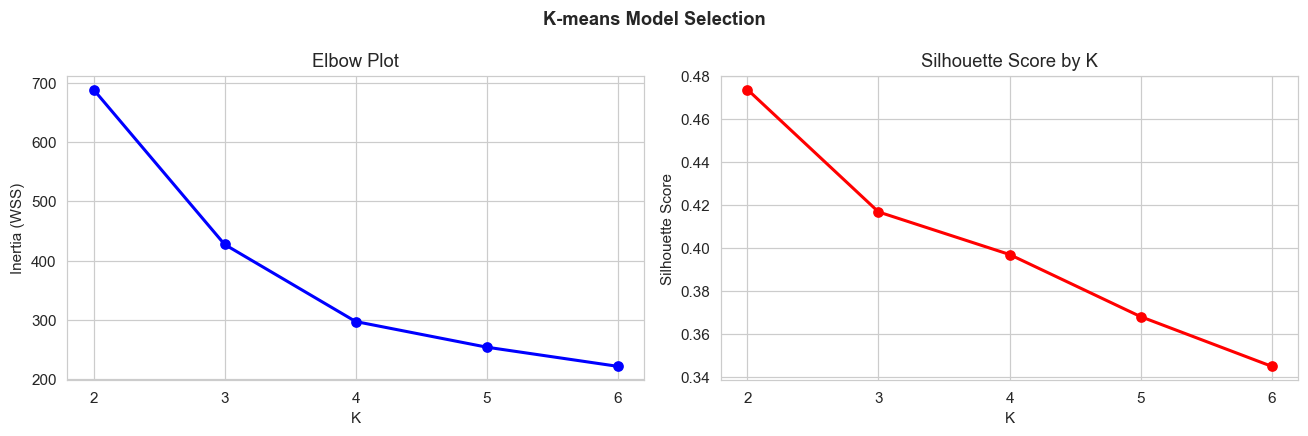

In [58]:
# ── Elbow and silhouette plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ks = list(K_RANGE)
axes[0].plot(ks, [km_results[k]["inertia"] for k in ks], "bo-", linewidth=2)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia (WSS)")
axes[0].set_title("Elbow Plot"); axes[0].set_xticks(ks)

axes[1].plot(ks, [km_results[k]["sil"] for k in ks], "ro-", linewidth=2)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K"); axes[1].set_xticks(ks)

plt.suptitle("K-means Model Selection", fontweight="bold")
plt.tight_layout()
plt.show()

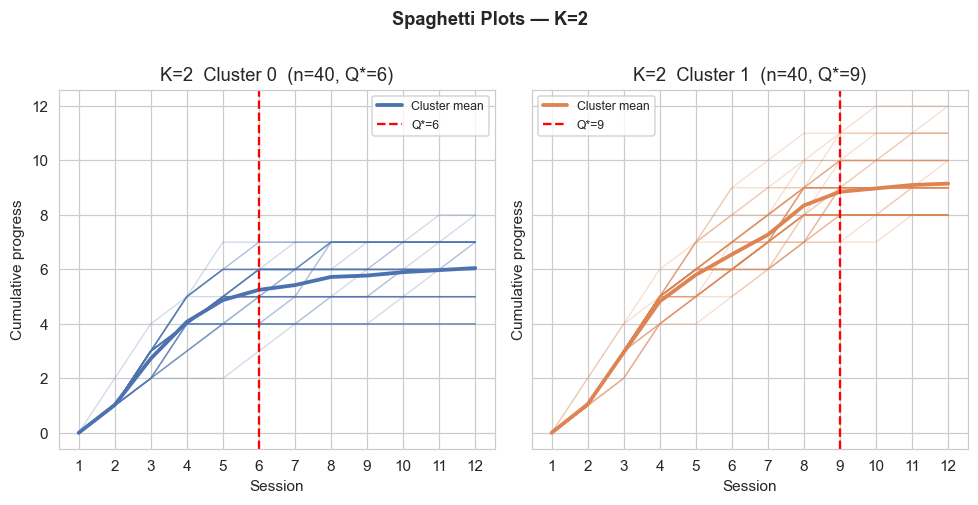

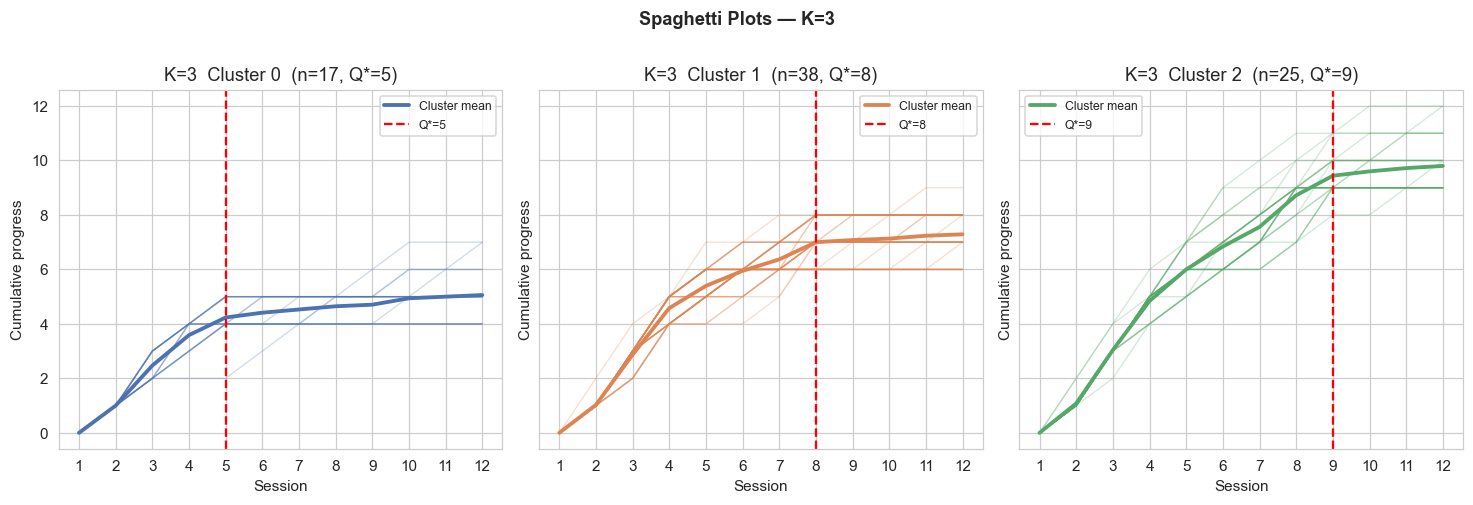

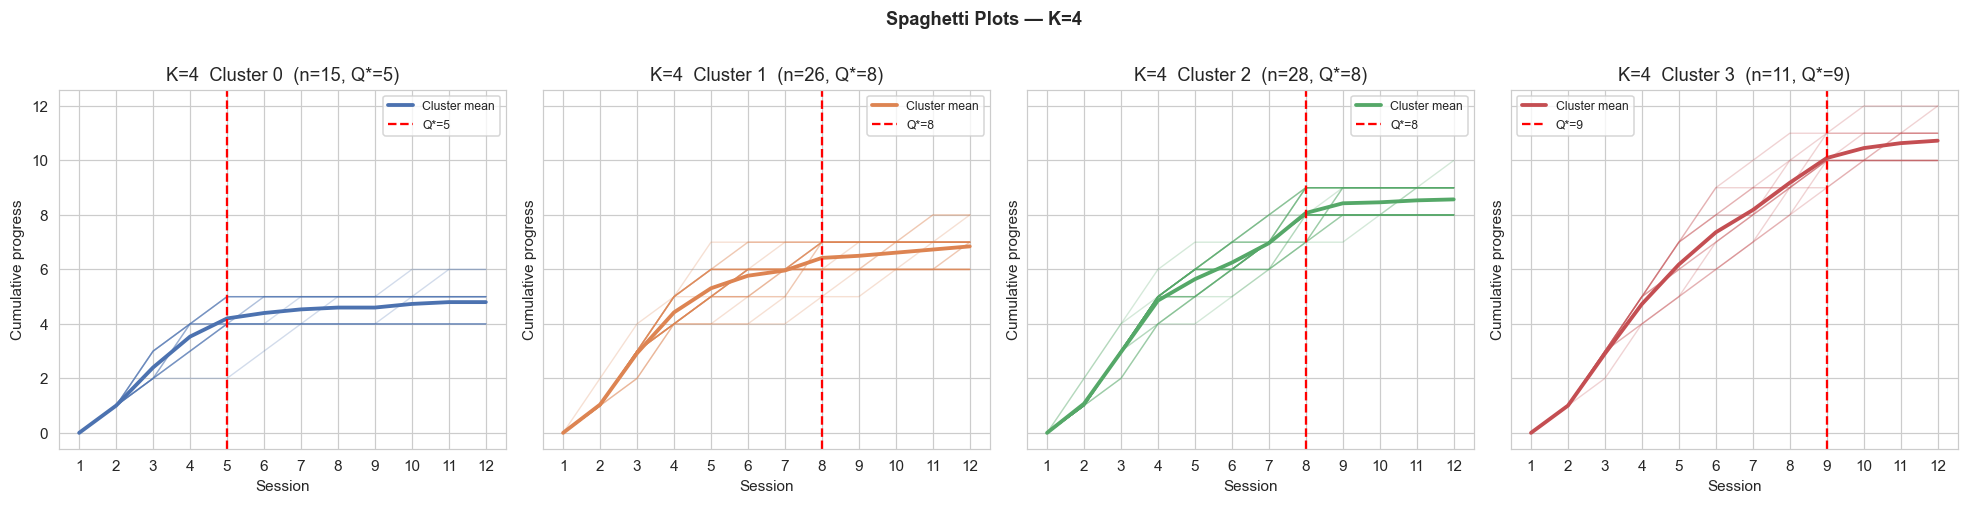

In [59]:
# ── Spaghetti plots for K = 2, 3, 4 ───────────────────────────────────────
for k in [2, 3, 4]:
    labels = km_results[k]["labels"]
    policy = all_policy[k]
    fig, axes_k = plt.subplots(1, k, figsize=(4.5 * k, 4.5), sharey=True)
    if k == 1:
        axes_k = [axes_k]

    for c, ax in enumerate(axes_k):
        mask  = labels == c
        color = COLORS[c]
        for traj in traj_matrix[mask]:
            ax.plot(SESSIONS, traj, color=color, alpha=0.25, linewidth=0.9)
        mean_traj = traj_matrix[mask].mean(axis=0)
        ax.plot(SESSIONS, mean_traj, color=color, linewidth=2.5, label="Cluster mean")
        qstar = policy[c]["qstar"]
        ax.axvline(qstar, color="red", linestyle="--", linewidth=1.5,
                   label=f"Q*={qstar}")
        ax.set_title(f"K={k}  Cluster {c}  (n={mask.sum()}, Q*={qstar})")
        ax.set_xlabel("Session"); ax.set_ylabel("Cumulative progress")
        ax.set_xticks(SESSIONS)
        ax.legend(fontsize=8)

    plt.suptitle(f"Spaghetti Plots — K={k}", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## Part (c) — Selecting K

**Final choice: K = 3.**

### Result-based rationale

Using the saved outputs from the notebook, K=3 is the best balance of separation,

policy usefulness, and simplicity:

- **K=2:** silhouette = 0.474, Q* values = [6, 9], expected sessions saved = 2.888 per child.
- **K=3:** silhouette = 0.417, Q* values = [5, 8, 9], expected sessions saved = 3.200 per child.
- **K=4:** silhouette = 0.397, Q* values = [5, 8, 8, 9], expected sessions saved = 3.163 per child.
- **K=5:** silhouette = 0.368, Q* values = [5, 8, 9, 8, 9], expected sessions saved = 3.188 per child.
- **K=6:** silhouette = 0.345, Q* values = [5, 6, 8, 9, 8, 9], expected sessions saved = 3.200 per child.

K=2 has the strongest silhouette, but it only yields two policy timings. K=3 is the first K
that gives three distinct, actionable reassessment sessions while also delivering the highest
expected savings per child among the simpler models. Although K=6 ties K=3 on expected savings,
it does so with substantially lower silhouette and more fragmented clusters.

For the selected K=3 solution, the saved results show:

- **Cluster 0 (Low-gain, n=17):** mean t*=6.76, Q*=5, E[saved]=4.118.
- **Cluster 1 (Mid-gain, n=38):** mean t*=7.82, Q*=8, E[saved]=3.158.
- **Cluster 2 (High-gain, n=25):** mean t*=8.48, Q*=9, E[saved]=2.640.

These results support K=3 as the most interpretable policy choice for the current data.

In [60]:
# ── Finalise K=3 ──────────────────────────────────────────────────────────
K_FINAL      = 3
final_labels = km_results[K_FINAL]["labels"]
final_policy = all_policy[K_FINAL]

CLUSTER_NAMES = ["Low-gain", "Mid-gain", "High-gain"]

print("Final cluster policy (K=3, sorted by mean final cumulative):")
for cr in final_policy:
    c = cr["cluster"]
    print(f"  Cluster {c} ({CLUSTER_NAMES[c]}): n={cr['n']:2d}, "
          f"mean t*={cr['mean_t*']:.2f}, Q*={cr['qstar']}, "
          f"E[saved]={cr['esaved']:.3f}")

Final cluster policy (K=3, sorted by mean final cumulative):
  Cluster 0 (Low-gain): n=17, mean t*=6.76, Q*=5, E[saved]=4.118
  Cluster 1 (Mid-gain): n=38, mean t*=7.82, Q*=8, E[saved]=3.158
  Cluster 2 (High-gain): n=25, mean t*=8.48, Q*=9, E[saved]=2.640


## Part (d) — Required Plots for K = 3

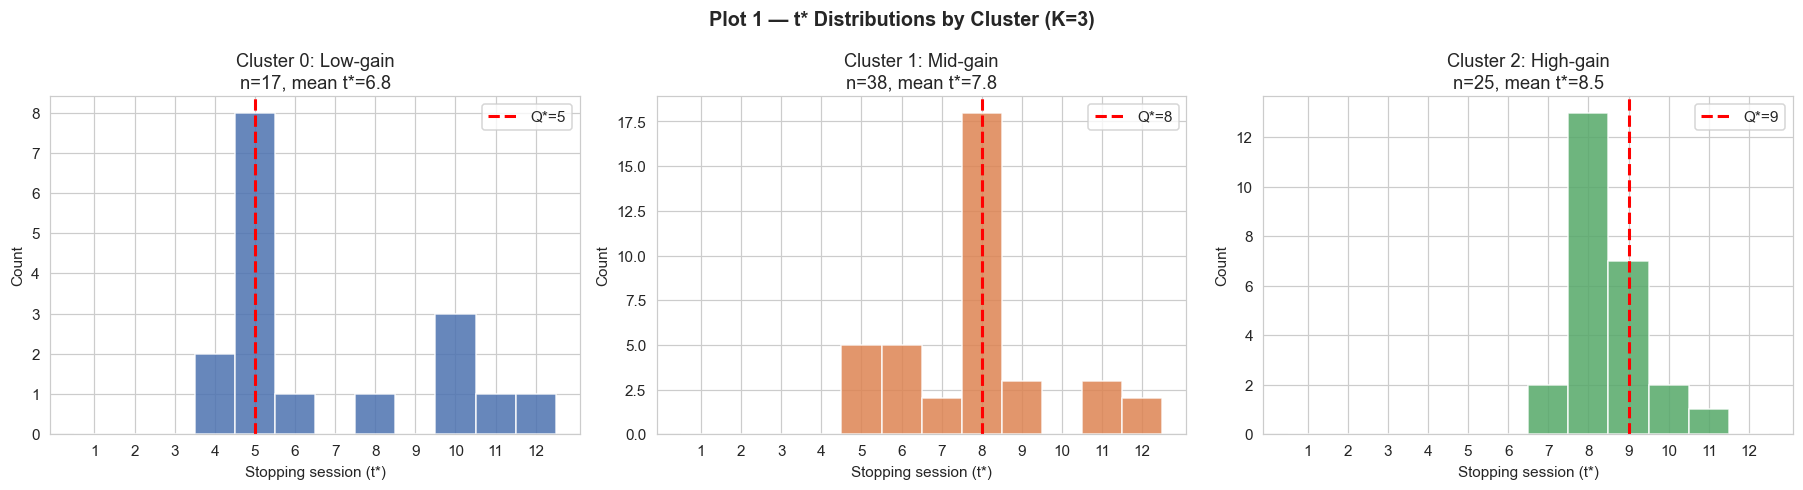

In [61]:
# ── Plot 1: t* distributions per cluster ──────────────────────────────────
fig, axes = plt.subplots(1, K_FINAL, figsize=(5.5 * K_FINAL, 4.5), sharey=False)
fig.suptitle("Plot 1 — t* Distributions by Cluster (K=3)",
             fontweight="bold", fontsize=13)

for c, ax in enumerate(axes):
    cr    = final_policy[c]
    color = COLORS[c]
    bins  = np.arange(0.5, 13.5, 1)
    ax.hist(cr["t_stars"], bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(cr["qstar"], color="red", linestyle="--", linewidth=2,
               label=f"Q*={cr['qstar']}")
    ax.set_title(f"Cluster {c}: {CLUSTER_NAMES[c]}\n"
                 f"n={cr['n']}, mean t*={cr['mean_t*']:.1f}")
    ax.set_xlabel("Stopping session (t*)")
    ax.set_ylabel("Count")
    ax.set_xticks(SESSIONS)
    ax.legend()

plt.tight_layout()
plt.show()

**Plot 1 interpretation.** The saved t* histograms show a clear ordering across the three
clusters. Cluster 0 is concentrated earlier and supports Q*=5. Cluster 1 shifts later and
supports Q*=8. Cluster 2 is latest overall and supports Q*=9. This confirms that the selected
K=3 solution separates clients into meaningfully different reassessment timings.

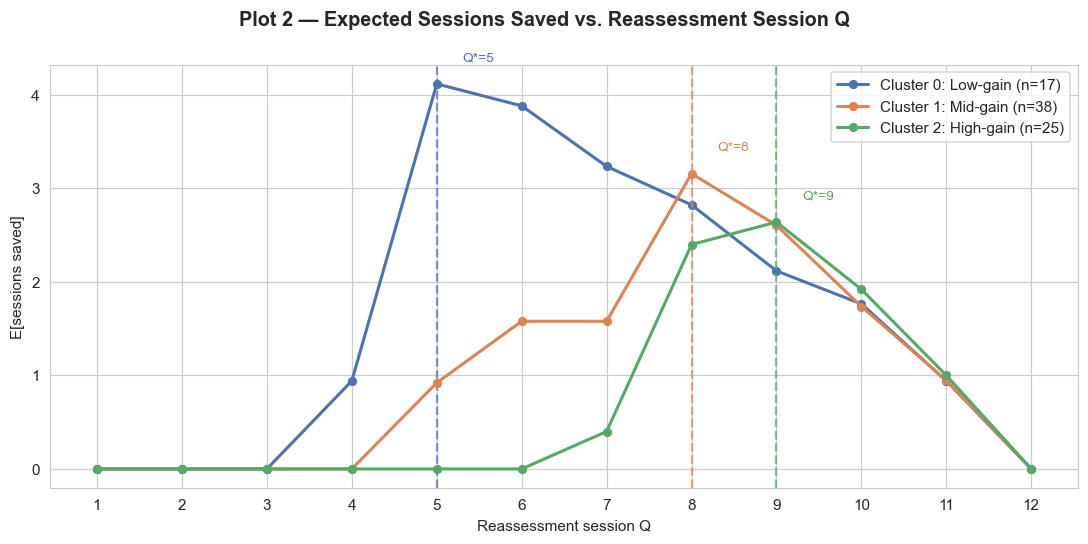

In [62]:
# ── Plot 2: E[savings](Q) curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Plot 2 — Expected Sessions Saved vs. Reassessment Session Q",
             fontweight="bold", fontsize=13)

for c, cr in enumerate(final_policy):
    ax.plot(SESSIONS, cr["savings_curve"], "o-",
            color=COLORS[c], linewidth=2, markersize=5,
            label=f"Cluster {c}: {CLUSTER_NAMES[c]} (n={cr['n']})")
    ax.axvline(cr["qstar"], color=COLORS[c], linestyle="--", linewidth=1.5, alpha=0.7)
    ax.annotate(f"Q*={cr['qstar']}",
                xy=(cr["qstar"], cr["savings_curve"][cr["qstar"] - 1]),
                xytext=(cr["qstar"] + 0.3, cr["savings_curve"][cr["qstar"] - 1] + 0.25),
                fontsize=9, color=COLORS[c])

ax.set_xlabel("Reassessment session Q")
ax.set_ylabel("E[sessions saved]")
ax.set_xticks(SESSIONS)
ax.legend()
plt.tight_layout()
plt.show()

**Plot 2 interpretation.** The expected-savings curves peak at Q=5, Q=8, and Q=9 for the
three selected clusters. That result matches the policy table exactly and shows why a single
audit session would be suboptimal: the low-gain group peaks earlier, while the mid-gain and
high-gain groups retain value from later reassessment.

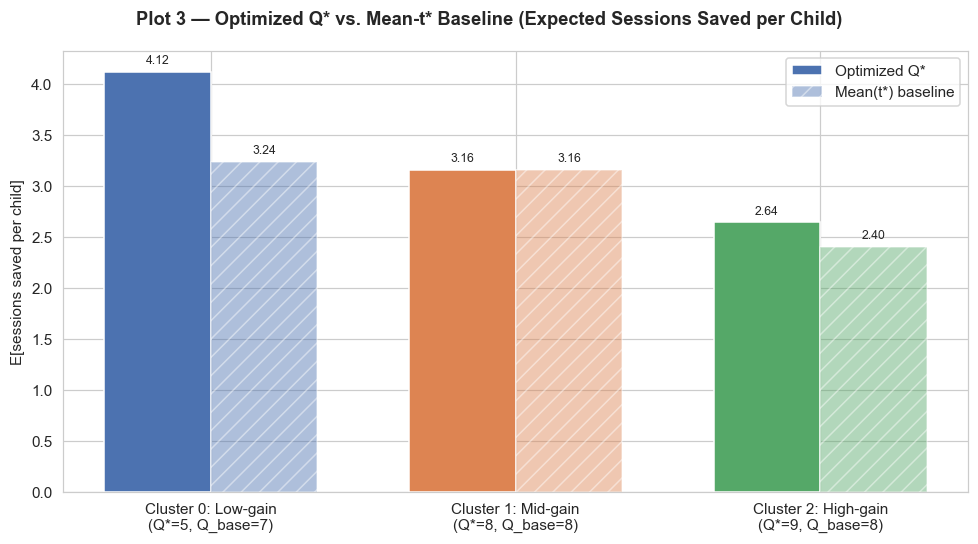

Overall expected sessions saved — Optimized: 256.0  (3.200/child)
Overall expected sessions saved — Baseline:  235.0  (2.938/child)
Gain from optimisation: 21.0 sessions across 80 historical clients


In [63]:
# ── Plot 3: Optimized Q* vs. mean(t*) baseline ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Plot 3 — Optimized Q* vs. Mean-t* Baseline (Expected Sessions Saved per Child)",
             fontweight="bold", fontsize=12)

x     = np.arange(K_FINAL)
width = 0.35
opt_savings  = [cr["esaved"] for cr in final_policy]
base_savings = [cr["ebase"]  for cr in final_policy]

bars1 = ax.bar(x - width / 2, opt_savings,  width, label="Optimized Q*",
               color=[COLORS[c] for c in range(K_FINAL)], edgecolor="white")
bars2 = ax.bar(x + width / 2, base_savings, width, label="Mean(t*) baseline",
               color=[COLORS[c] for c in range(K_FINAL)], edgecolor="white",
               alpha=0.45, hatch="//")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c}: {CLUSTER_NAMES[c]}\n"
                    f"(Q*={final_policy[c]['qstar']}, Q_base={final_policy[c]['qbase']})"
                    for c in range(K_FINAL)])
ax.set_ylabel("E[sessions saved per child]")
ax.legend()
plt.tight_layout()
plt.show()

# ── Overall savings comparison ─────────────────────────────────────────────
n_total   = len(client_ids)
total_opt  = sum(cr["esaved"] * cr["n"] for cr in final_policy)
total_base = sum(cr["ebase"]  * cr["n"] for cr in final_policy)
print(f"Overall expected sessions saved — Optimized: {total_opt:.1f}  "
      f"({total_opt/n_total:.3f}/child)")
print(f"Overall expected sessions saved — Baseline:  {total_base:.1f}  "
      f"({total_base/n_total:.3f}/child)")
print(f"Gain from optimisation: {total_opt - total_base:.1f} sessions "
      f"across {n_total} historical clients")

**Plot 3 interpretation.** Relative to the mean-t* baseline, the optimized policy mainly adds
value by moving Cluster 0 earlier and Cluster 2 later. For the current saved results, Cluster 1
already aligns closely with the baseline at Q=8, while the optimized policy improves the overall
average from 2.938 to 3.200 expected sessions saved per child.

## Part (e) — Summary Table and Cluster Labels

In [64]:
n_total = len(client_ids)
rows = []
for cr in final_policy:
    c = cr["cluster"]
    pct_saved = cr["esaved"] / TMAX * 100
    rows.append({
        "Cluster": f"Cluster {c}: {CLUSTER_NAMES[c]}",
        "Size": cr["n"],
        "Q*": cr["qstar"],
        "E[saved/child]": f"{cr['esaved']:.3f}",
        "% sessions saved": f"{pct_saved:.1f}%",
    })

total_esaved_per_child = sum(cr["esaved"] * cr["n"] for cr in final_policy) / n_total
rows.append({
    "Cluster": "Total",
    "Size": n_total,
    "Q*": "—",
    "E[saved/child]": f"{total_esaved_per_child:.3f}",
    "% sessions saved": f"{total_esaved_per_child / TMAX * 100:.1f}%",
})

summary_df = pd.DataFrame(rows)
display(summary_df)

,Cluster,Size,Q*,E[saved/child],% sessions saved
0,Cluster 0: Low-gain,17,5,4.118,34.3%
1,Cluster 1: Mid-gain,38,8,3.158,26.3%
2,Cluster 2: High-gain,25,9,2.640,22.0%
3,Total,80,—,3.200,26.7%


## Part (f) — Implications for the Westfield Case

### Do the clusters support Chen and Patel's claim?

**Yes — strongly.** Chen and Patel observed that clients who receive the same nominal pathway
can still progress very differently through care. The current saved results support that claim:
across **80 historical clients**, the K=3 solution separates the cohort into three groups with
different stopping-point profiles and different reassessment policies.

- **Low-gain clients (Cluster 0, n=17)** have the earliest stopping profile, with mean t*=6.76
  and an optimal reassessment session of Q*=5.
- **Mid-gain clients (Cluster 1, n=38)** sit in the middle, with mean t*=7.82 and Q*=8.
- **High-gain clients (Cluster 2, n=25)** are latest overall, with mean t*=8.48 and Q*=9.

### What the differentiated reassessment policy suggests for planning

1. **Cluster-specific scheduling is more efficient than a uniform policy.** The optimized K=3
   policy saves **3.200 sessions per child on average (26.7% of the 12-session pathway)**,
   compared with **2.938** under the mean-t* baseline. That is a gain of **21.0 sessions**
   across the 80 historical clients in the saved results.

2. **Early reassessment is mainly justified for Cluster 0.** Its optimal timing is Q*=5,
   materially earlier than the other groups, which is consistent with Patel's intuition that
   some clients plateau relatively quickly.

3. **Higher-gain groups should not be audited too early.** The saved results place Cluster 1 at
   Q*=8 and Cluster 2 at Q*=9, so a uniform early audit would leave expected savings on the
   table for these later-progressing clients.

4. **Cluster assignment still requires intake prediction (Q3).** The reassessment policy becomes
   actionable for new clients only if we can predict likely cluster membership before treatment
   trajectories are observed.